In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
from datetime import datetime, date, time, timedelta


plt.style.use('bmh')

Getting Data

In [2]:
df = pd.read_csv('data/King_county_house.csv')
df_test = pd.read_csv('data/King_county_house.csv')
df.head()

,sales_id,house_id,date,price,bedrooms_num,bathrooms_num,sqft_living,sqft_lot,floors_total,waterfront,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,1,7129300520,2014-10-13,221900.0,3.0,1.00,1180.0,5650.0,1.0,NaN,...,7,1180.0,0.0,1955,0.0,98178,47.5112,-122.257,1340.0,5650.0
1,2,6414100192,2014-12-09,538000.0,3.0,2.25,2570.0,7242.0,2.0,0.0,...,7,2170.0,400.0,1951,19910.0,98125,47.7210,-122.319,1690.0,7639.0
2,3,5631500400,2015-02-25,180000.0,2.0,1.00,770.0,10000.0,1.0,0.0,...,6,770.0,0.0,1933,NaN,98028,47.7379,-122.233,2720.0,8062.0
3,4,2487200875,2014-12-09,604000.0,4.0,3.00,1960.0,5000.0,1.0,0.0,...,7,1050.0,910.0,1965,0.0,98136,47.5208,-122.393,1360.0,5000.0
4,5,1954400510,2015-02-18,510000.0,3.0,2.00,1680.0,8080.0,1.0,0.0,...,8,1680.0,0.0,1987,0.0,98074,47.6168,-122.045,1800.0,7503.0


In [3]:
df.shape

(21597, 22)

Convert date to datetime format 

In [4]:
df.date = pd.to_datetime(df.date)
df.dtypes

sales_id                  int64
house_id                  int64
date             datetime64[ns]
price                   float64
bedrooms_num            float64
bathrooms_num           float64
sqft_living             float64
sqft_lot                float64
floors_total            float64
waterfront              float64
view                    float64
condition                 int64
grade                     int64
sqft_above              float64
sqft_basement           float64
yr_built                  int64
yr_renovated            float64
zipcode                   int64
lat                     float64
long                    float64
sqft_living15           float64
sqft_lot15              float64
dtype: object

Create new column for year and month

In [5]:
df['year'] = df.date.dt.year

# Create new column for year-month
df['month'] = df['date'].dt.strftime('%m')
df.tail(10)

,sales_id,house_id,date,price,bedrooms_num,bathrooms_num,sqft_living,sqft_lot,floors_total,waterfront,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,year,month
21587,21588,7852140040,2014-08-25,507250.0,3.0,2.50,2270.0,5536.0,2.0,NaN,...,0.0,2003,0.0,98065,47.5389,-121.881,2270.0,5731.0,2014,08
21588,21589,9834201367,2015-01-26,429000.0,3.0,2.00,1490.0,1126.0,3.0,0.0,...,0.0,2014,0.0,98144,47.5699,-122.288,1400.0,1230.0,2015,01
21589,21590,3448900210,2014-10-14,610685.0,4.0,2.50,2520.0,6023.0,2.0,0.0,...,0.0,2014,0.0,98056,47.5137,-122.167,2520.0,6023.0,2014,10
21590,21591,7936000429,2015-03-26,1010000.0,4.0,3.50,3510.0,7200.0,2.0,0.0,...,910.0,2009,0.0,98136,47.5537,-122.398,2050.0,6200.0,2015,03
21591,21592,2997800021,2015-02-19,475000.0,3.0,2.50,1310.0,1294.0,2.0,0.0,...,130.0,2008,0.0,98116,47.5773,-122.409,1330.0,1265.0,2015,02
21592,21593,263000018,2014-05-21,360000.0,3.0,2.50,1530.0,1131.0,3.0,0.0,...,0.0,2009,0.0,98103,47.6993,-122.346,1530.0,1509.0,2014,05
21593,21594,6600060120,2015-02-23,400000.0,4.0,2.50,2310.0,5813.0,2.0,0.0,...,0.0,2014,0.0,98146,47.5107,-122.362,1830.0,7200.0,2015,02
21594,21595,1523300141,2014-06-23,402101.0,2.0,0.75,1020.0,1350.0,2.0,0.0,...,0.0,2009,0.0,98144,47.5944,-122.299,1020.0,2007.0,2014,06
21595,21596,291310100,2015-01-16,400000.0,3.0,2.50,1600.0,2388.0,2.0,NaN,...,0.0,2004,0.0,98027,47.5345,-122.069,1410.0,1287.0,2015,01
21596,21597,1523300157,2014-10-15,325000.0,2.0,0.75,1020.0,1076.0,2.0,0.0,...,0.0,2008,0.0,98144,47.5941,-122.299,1020.0,1357.0,2014,10


In [6]:
#information about the DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21597 entries, 0 to 21596
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   sales_id       21597 non-null  int64         
 1   house_id       21597 non-null  int64         
 2   date           21597 non-null  datetime64[ns]
 3   price          21597 non-null  float64       
 4   bedrooms_num   21597 non-null  float64       
 5   bathrooms_num  21597 non-null  float64       
 6   sqft_living    21597 non-null  float64       
 7   sqft_lot       21597 non-null  float64       
 8   floors_total   21597 non-null  float64       
 9   waterfront     19206 non-null  float64       
 10  view           21534 non-null  float64       
 11  condition      21597 non-null  int64         
 12  grade          21597 non-null  int64         
 13  sqft_above     21597 non-null  float64       
 14  sqft_basement  21145 non-null  float64       
 15  yr_built       2159

In [7]:
# Get the basic statistics
df.describe().transpose()


,count,mean,min,25%,50%,75%,max,std
sales_id,21597.0,10799.0,1.0,5400.0,10799.0,16198.0,21597.0,6234.661218
house_id,21597.0,4580474287.770987,1000102.0,2123049175.0,3904930410.0,7308900490.0,9900000190.0,2876735715.74778
date,21597,2014-10-29 04:20:38.171968512,2014-05-02 00:00:00,2014-07-22 00:00:00,2014-10-16 00:00:00,2015-02-17 00:00:00,2015-05-27 00:00:00,NaN
price,21597.0,540296.573506,78000.0,322000.0,450000.0,645000.0,7700000.0,367368.140101
bedrooms_num,21597.0,3.3732,1.0,3.0,3.0,4.0,33.0,0.926299
bathrooms_num,21597.0,2.115826,0.5,1.75,2.25,2.5,8.0,0.768984
sqft_living,21597.0,2080.32185,370.0,1430.0,1910.0,2550.0,13540.0,918.106125
sqft_lot,21597.0,15099.40876,520.0,5040.0,7618.0,10685.0,1651359.0,41412.636876
floors_total,21597.0,1.494096,1.0,1.0,1.5,2.0,3.5,0.539683
waterfront,19206.0,0.007602,0.0,0.0,0.0,0.0,1.0,0.086858


Cleaning data / NaN / Data Types

In [8]:
print("number of NaN values for the column bedrooms :", df['bedrooms_num'].isnull().sum())
print("number of NaN values for the column bathrooms :", df['bathrooms_num'].isnull().sum())

number of NaN values for the column bedrooms : 0
number of NaN values for the column bathrooms : 0


In [9]:
df.isnull().sum()

sales_id            0
house_id            0
date                0
price               0
bedrooms_num        0
bathrooms_num       0
sqft_living         0
sqft_lot            0
floors_total        0
waterfront       2391
view               63
condition           0
grade               0
sqft_above          0
sqft_basement     452
yr_built            0
yr_renovated     3848
zipcode             0
lat                 0
long                0
sqft_living15       0
sqft_lot15          0
year                0
month               0
dtype: int64

In [10]:
# Missing data?
df.isna().sum()

sales_id            0
house_id            0
date                0
price               0
bedrooms_num        0
bathrooms_num       0
sqft_living         0
sqft_lot            0
floors_total        0
waterfront       2391
view               63
condition           0
grade               0
sqft_above          0
sqft_basement     452
yr_built            0
yr_renovated     3848
zipcode             0
lat                 0
long                0
sqft_living15       0
sqft_lot15          0
year                0
month               0
dtype: int64

In [11]:
columns_of_interest = ['date', 'price', 'bedrooms_num', 'sqft_living', 'waterfront', 'view', 'condition', 'sqft_basement', 'yr_renovated']
nan_counts = df[columns_of_interest].isna().sum()
nan_counts

date                0
price               0
bedrooms_num        0
sqft_living         0
waterfront       2391
view               63
condition           0
sqft_basement     452
yr_renovated     3848
dtype: int64

In [12]:
df[df['waterfront'].isna()]

,sales_id,house_id,date,price,bedrooms_num,bathrooms_num,sqft_living,sqft_lot,floors_total,waterfront,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,year,month
0,1,7129300520,2014-10-13,221900.0,3.0,1.00,1180.0,5650.0,1.0,NaN,...,0.0,1955,0.0,98178,47.5112,-122.257,1340.0,5650.0,2014,10
10,11,1736800520,2015-04-03,662500.0,3.0,2.50,3560.0,9796.0,1.0,NaN,...,1700.0,1965,0.0,98007,47.6007,-122.145,2210.0,8925.0,2015,04
23,24,8091400200,2014-05-16,252700.0,2.0,1.50,1070.0,9643.0,1.0,NaN,...,0.0,1985,NaN,98030,47.3533,-122.166,1220.0,8386.0,2014,05
40,41,5547700270,2014-07-15,625000.0,4.0,2.50,2570.0,5520.0,2.0,NaN,...,0.0,2000,NaN,98074,47.6145,-122.027,2470.0,5669.0,2014,07
55,56,9822700295,2014-05-12,885000.0,4.0,2.50,2830.0,5000.0,2.0,NaN,...,0.0,1995,0.0,98105,47.6597,-122.290,1950.0,5000.0,2014,05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21578,21579,5087900040,2014-10-17,350000.0,4.0,2.75,2500.0,5995.0,2.0,NaN,...,0.0,2008,0.0,98042,47.3749,-122.107,2530.0,5988.0,2014,10
21582,21583,8956200760,2014-10-13,541800.0,4.0,2.50,3118.0,7866.0,2.0,NaN,...,0.0,2014,0.0,98001,47.2931,-122.264,2673.0,6500.0,2014,10
21586,21587,844000965,2014-06-26,224000.0,3.0,1.75,1500.0,11968.0,1.0,NaN,...,0.0,2014,0.0,98010,47.3095,-122.002,1320.0,11303.0,2014,06
21587,21588,7852140040,2014-08-25,507250.0,3.0,2.50,2270.0,5536.0,2.0,NaN,...,0.0,2003,0.0,98065,47.5389,-121.881,2270.0,5731.0,2014,08


Handle missing values by filling with 0 and convert to integer type

In [13]:
df['waterfront']=df['waterfront'].fillna(0.)
df['waterfront'] = df['waterfront'].astype(int)

In [14]:
df['waterfront'].unique()

array([0, 1])

View: NaN -> 0

In [15]:
df['view'].unique()

array([ 0., nan,  3.,  4.,  2.,  1.])

In [16]:
df['view']=df['view'].fillna(0.)
df['view'] = df['view'].astype(int)

Yr_revovated: NaN -> 0

In [17]:
df['yr_renovated'].unique()

array([    0., 19910.,    nan, 20020., 20100., 19920., 20130., 19940.,
       19780., 20050., 20030., 19840., 19540., 20140., 20110., 19830.,
       19450., 19900., 19880., 19770., 19810., 19950., 20000., 19990.,
       19980., 19700., 19890., 20040., 19860., 20070., 19870., 20060.,
       19850., 20010., 19800., 19710., 19790., 19970., 19500., 19690.,
       19480., 20090., 20150., 19740., 20080., 19680., 20120., 19630.,
       19510., 19620., 19530., 19930., 19960., 19550., 19820., 19560.,
       19400., 19760., 19460., 19750., 19640., 19730., 19570., 19590.,
       19600., 19670., 19650., 19340., 19720., 19440., 19580.])

In [18]:
# Fill missing renovation years with 0
df['yr_renovated'].fillna(0., inplace=True)

/var/folders/6g/9nftk1_n2h77z8xpm0tdmdsw0000gn/T/ipykernel_64885/4006329345.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['yr_renovated'].fillna(0., inplace=True)


In [19]:
# Transform year to integer 

df['yr_renovated'] = df['yr_renovated']/10
df['yr_renovated'] = df['yr_renovated'].astype(int)

In [20]:
df['yr_renovated'].unique()

array([   0, 1991, 2002, 2010, 1992, 2013, 1994, 1978, 2005, 2003, 1984,
       1954, 2014, 2011, 1983, 1945, 1990, 1988, 1977, 1981, 1995, 2000,
       1999, 1998, 1970, 1989, 2004, 1986, 2007, 1987, 2006, 1985, 2001,
       1980, 1971, 1979, 1997, 1950, 1969, 1948, 2009, 2015, 1974, 2008,
       1968, 2012, 1963, 1951, 1962, 1953, 1993, 1996, 1955, 1982, 1956,
       1940, 1976, 1946, 1975, 1964, 1973, 1957, 1959, 1960, 1967, 1965,
       1934, 1972, 1944, 1958])

Calculate missing basement square footage
Formula: Total Living Area - Above Ground Living Area
Sqft_basement: sqft_living - sqft_above

In [21]:
# Check the number of rows where 'sqft_basement' is missing (NaN)
df[df['sqft_basement'].isna()].shape

(452, 24)

Testing dependence of sqft_basement

In [22]:
df_test_copy = df_test[['sqft_living', 'sqft_above','sqft_basement']].copy()
df_test_copy[df_test_copy['sqft_basement'].isna()]

,sqft_living,sqft_above,sqft_basement
6,1715.0,1715.0,NaN
18,1200.0,1200.0,NaN
42,3595.0,3595.0,NaN
79,3450.0,3450.0,NaN
112,1540.0,1160.0,NaN
...,...,...,...
21442,2360.0,1390.0,NaN
21447,2330.0,2330.0,NaN
21473,980.0,980.0,NaN
21519,2380.0,2380.0,NaN


In [23]:
# Create a new column 'sum_sq' by adding 'sqft_above' and 'sqft_basement' directly in the DataFrame
df_test_copy.eval('sum_sq = sqft_above + sqft_basement', inplace = True)
df_test_copy

,sqft_living,sqft_above,sqft_basement,sum_sq
0,1180.0,1180.0,0.0,1180.0
1,2570.0,2170.0,400.0,2570.0
2,770.0,770.0,0.0,770.0
3,1960.0,1050.0,910.0,1960.0
4,1680.0,1680.0,0.0,1680.0
...,...,...,...,...
21592,1530.0,1530.0,0.0,1530.0
21593,2310.0,2310.0,0.0,2310.0
21594,1020.0,1020.0,0.0,1020.0
21595,1600.0,1600.0,0.0,1600.0


In [24]:
# Calculate the difference between the total calculated area and the original 'sqft_living'
df_test_copy.eval('diff_sq = sum_sq - sqft_living', inplace = True)
df_test_copy

,sqft_living,sqft_above,sqft_basement,sum_sq,diff_sq
0,1180.0,1180.0,0.0,1180.0,0.0
1,2570.0,2170.0,400.0,2570.0,0.0
2,770.0,770.0,0.0,770.0,0.0
3,1960.0,1050.0,910.0,1960.0,0.0
4,1680.0,1680.0,0.0,1680.0,0.0
...,...,...,...,...,...
21592,1530.0,1530.0,0.0,1530.0,0.0
21593,2310.0,2310.0,0.0,2310.0,0.0
21594,1020.0,1020.0,0.0,1020.0,0.0
21595,1600.0,1600.0,0.0,1600.0,0.0


In [25]:
# Verify that all 'sqft_basement' missing values have been successfully handled
df[df['sqft_basement'].isna()]


,sales_id,house_id,date,price,bedrooms_num,bathrooms_num,sqft_living,sqft_lot,floors_total,waterfront,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,year,month
6,7,1321400060,2014-06-27,257500.0,3.0,2.25,1715.0,6819.0,2.0,0,...,NaN,1995,0,98003,47.3097,-122.327,2238.0,6819.0,2014,06
18,19,16000397,2014-12-05,189000.0,2.0,1.00,1200.0,9850.0,1.0,0,...,NaN,1921,0,98002,47.3089,-122.210,1060.0,5095.0,2014,12
42,43,7203220400,2014-07-07,861990.0,5.0,2.75,3595.0,5639.0,2.0,0,...,NaN,2014,0,98053,47.6848,-122.016,3625.0,5639.0,2014,07
79,80,1531000030,2015-03-23,720000.0,4.0,2.50,3450.0,39683.0,2.0,0,...,NaN,2002,0,98010,47.3420,-122.025,3350.0,39750.0,2015,03
112,113,2525310310,2014-09-16,272500.0,3.0,1.75,1540.0,12600.0,1.0,0,...,NaN,1980,0,98038,47.3624,-122.031,1540.0,11656.0,2014,09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21442,21443,3226049565,2014-07-11,504600.0,5.0,3.00,2360.0,5000.0,1.0,0,...,NaN,2008,0,98103,47.6931,-122.330,2180.0,5009.0,2014,07
21447,21448,1760650900,2014-07-21,337500.0,4.0,2.50,2330.0,4907.0,2.0,0,...,NaN,2013,0,98042,47.3590,-122.081,2300.0,3836.0,2014,07
21473,21474,6021503707,2015-01-20,352500.0,2.0,2.50,980.0,1010.0,3.0,0,...,NaN,2008,0,98117,47.6844,-122.387,980.0,1023.0,2015,01
21519,21520,2909310100,2014-10-15,332000.0,4.0,2.50,2380.0,5737.0,2.0,0,...,NaN,2010,0,98023,47.2815,-122.356,2380.0,5396.0,2014,10


In [26]:
# Fill missing 'sqft_basement' values by calculating the difference between total living area and above-ground area
df['sqft_basement']=df['sqft_basement'].fillna(df['sqft_living'] - df['sqft_above'])

In [27]:
df.isnull().sum()

sales_id         0
house_id         0
date             0
price            0
bedrooms_num     0
bathrooms_num    0
sqft_living      0
sqft_lot         0
floors_total     0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
year             0
month            0
dtype: int64

Dealing with duplicates

In [28]:
# check how many duplicated rows exist in the data frame
df.duplicated().value_counts()

False    21597
Name: count, dtype: int64

In [31]:
df.to_csv('data/King_country_house_clean_all_ohheNaN.csv',index=False)

In [30]:
df.shape

(21597, 24)

In [32]:
# Look for duplicate data using lat/long
# Identify rows with duplicate latitude and longitude coordinates
# Sort them by latitude and display the first 10 rows for inspection

df[df.duplicated(subset=['lat','long'], keep=False)].sort_values('lat').head(10)

,sales_id,house_id,date,price,bedrooms_num,bathrooms_num,sqft_living,sqft_lot,floors_total,waterfront,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,year,month
20909,20910,8141310040,2014-06-27,246950.0,3.0,3.00,1670.0,4440.0,1.0,0,...,0.0,2014,0,98022,47.1948,-121.975,1670.0,4622.0,2014,06
20670,20671,8141310030,2014-07-30,256703.0,3.0,2.00,1670.0,4441.0,1.0,0,...,0.0,2014,0,98022,47.1948,-121.975,1670.0,4622.0,2014,07
16521,16522,5595900345,2015-01-13,460000.0,4.0,2.75,3460.0,13168.0,2.0,0,...,0.0,1932,1986,98022,47.2046,-121.996,1500.0,7670.0,2015,01
5142,5143,5595900280,2015-03-18,235000.0,3.0,1.00,1050.0,7670.0,1.5,0,...,0.0,1955,0,98022,47.2046,-121.996,1220.0,7670.0,2015,03
8422,8423,9432900180,2014-07-14,307999.0,4.0,2.75,2420.0,8438.0,2.0,0,...,0.0,1996,0,98022,47.2091,-122.009,2420.0,8580.0,2014,07
7163,7164,9432900380,2014-10-23,280017.0,3.0,2.50,1850.0,8770.0,2.0,0,...,0.0,1996,0,98022,47.2091,-122.009,2350.0,8606.0,2014,10
14772,14773,2420069604,2015-03-30,255000.0,3.0,2.50,1720.0,6200.0,2.0,0,...,0.0,2014,0,98022,47.2137,-121.989,1710.0,9520.0,2015,03
8122,8123,2420069278,2015-03-19,287000.0,3.0,2.50,1820.0,8722.0,1.5,0,...,0.0,1926,2008,98022,47.2137,-121.989,1480.0,12285.0,2015,03
13276,13277,3750605674,2014-09-17,270000.0,3.0,2.50,1808.0,19200.0,1.0,0,...,0.0,2005,0,98001,47.2598,-122.281,1450.0,14400.0,2014,09
7897,7898,3750605620,2015-03-24,225000.0,3.0,1.75,1580.0,14400.0,1.0,0,...,0.0,1981,0,98001,47.2598,-122.281,1480.0,9600.0,2015,03


In [33]:
# Create a new DataFrame 'df_l' containing only specific columns for simplified analysis
df_l=df[['house_id','date','price','sqft_living','lat','long']].copy()
df_l


,house_id,date,price,sqft_living,lat,long
0,7129300520,2014-10-13,221900.0,1180.0,47.5112,-122.257
1,6414100192,2014-12-09,538000.0,2570.0,47.7210,-122.319
2,5631500400,2015-02-25,180000.0,770.0,47.7379,-122.233
3,2487200875,2014-12-09,604000.0,1960.0,47.5208,-122.393
4,1954400510,2015-02-18,510000.0,1680.0,47.6168,-122.045
...,...,...,...,...,...,...
21592,263000018,2014-05-21,360000.0,1530.0,47.6993,-122.346
21593,6600060120,2015-02-23,400000.0,2310.0,47.5107,-122.362
21594,1523300141,2014-06-23,402101.0,1020.0,47.5944,-122.299
21595,291310100,2015-01-16,400000.0,1600.0,47.5345,-122.069


In [34]:
df_l[df_l.duplicated(subset=['lat','long'],keep=False)].sort_values('lat').head(8)

,house_id,date,price,sqft_living,lat,long
20909,8141310040,2014-06-27,246950.0,1670.0,47.1948,-121.975
20670,8141310030,2014-07-30,256703.0,1670.0,47.1948,-121.975
16521,5595900345,2015-01-13,460000.0,3460.0,47.2046,-121.996
5142,5595900280,2015-03-18,235000.0,1050.0,47.2046,-121.996
8422,9432900180,2014-07-14,307999.0,2420.0,47.2091,-122.009
7163,9432900380,2014-10-23,280017.0,1850.0,47.2091,-122.009
14772,2420069604,2015-03-30,255000.0,1720.0,47.2137,-121.989
8122,2420069278,2015-03-19,287000.0,1820.0,47.2137,-121.989


In [35]:
# We have a lot of duplicate entries. We're going to keep the later of these entries and hope that if it's an outlier,
# it's caught in our outlier processing later.

df.drop_duplicates(['lat','long'], keep='last', inplace=True)

In [36]:
df.shape

(20818, 24)

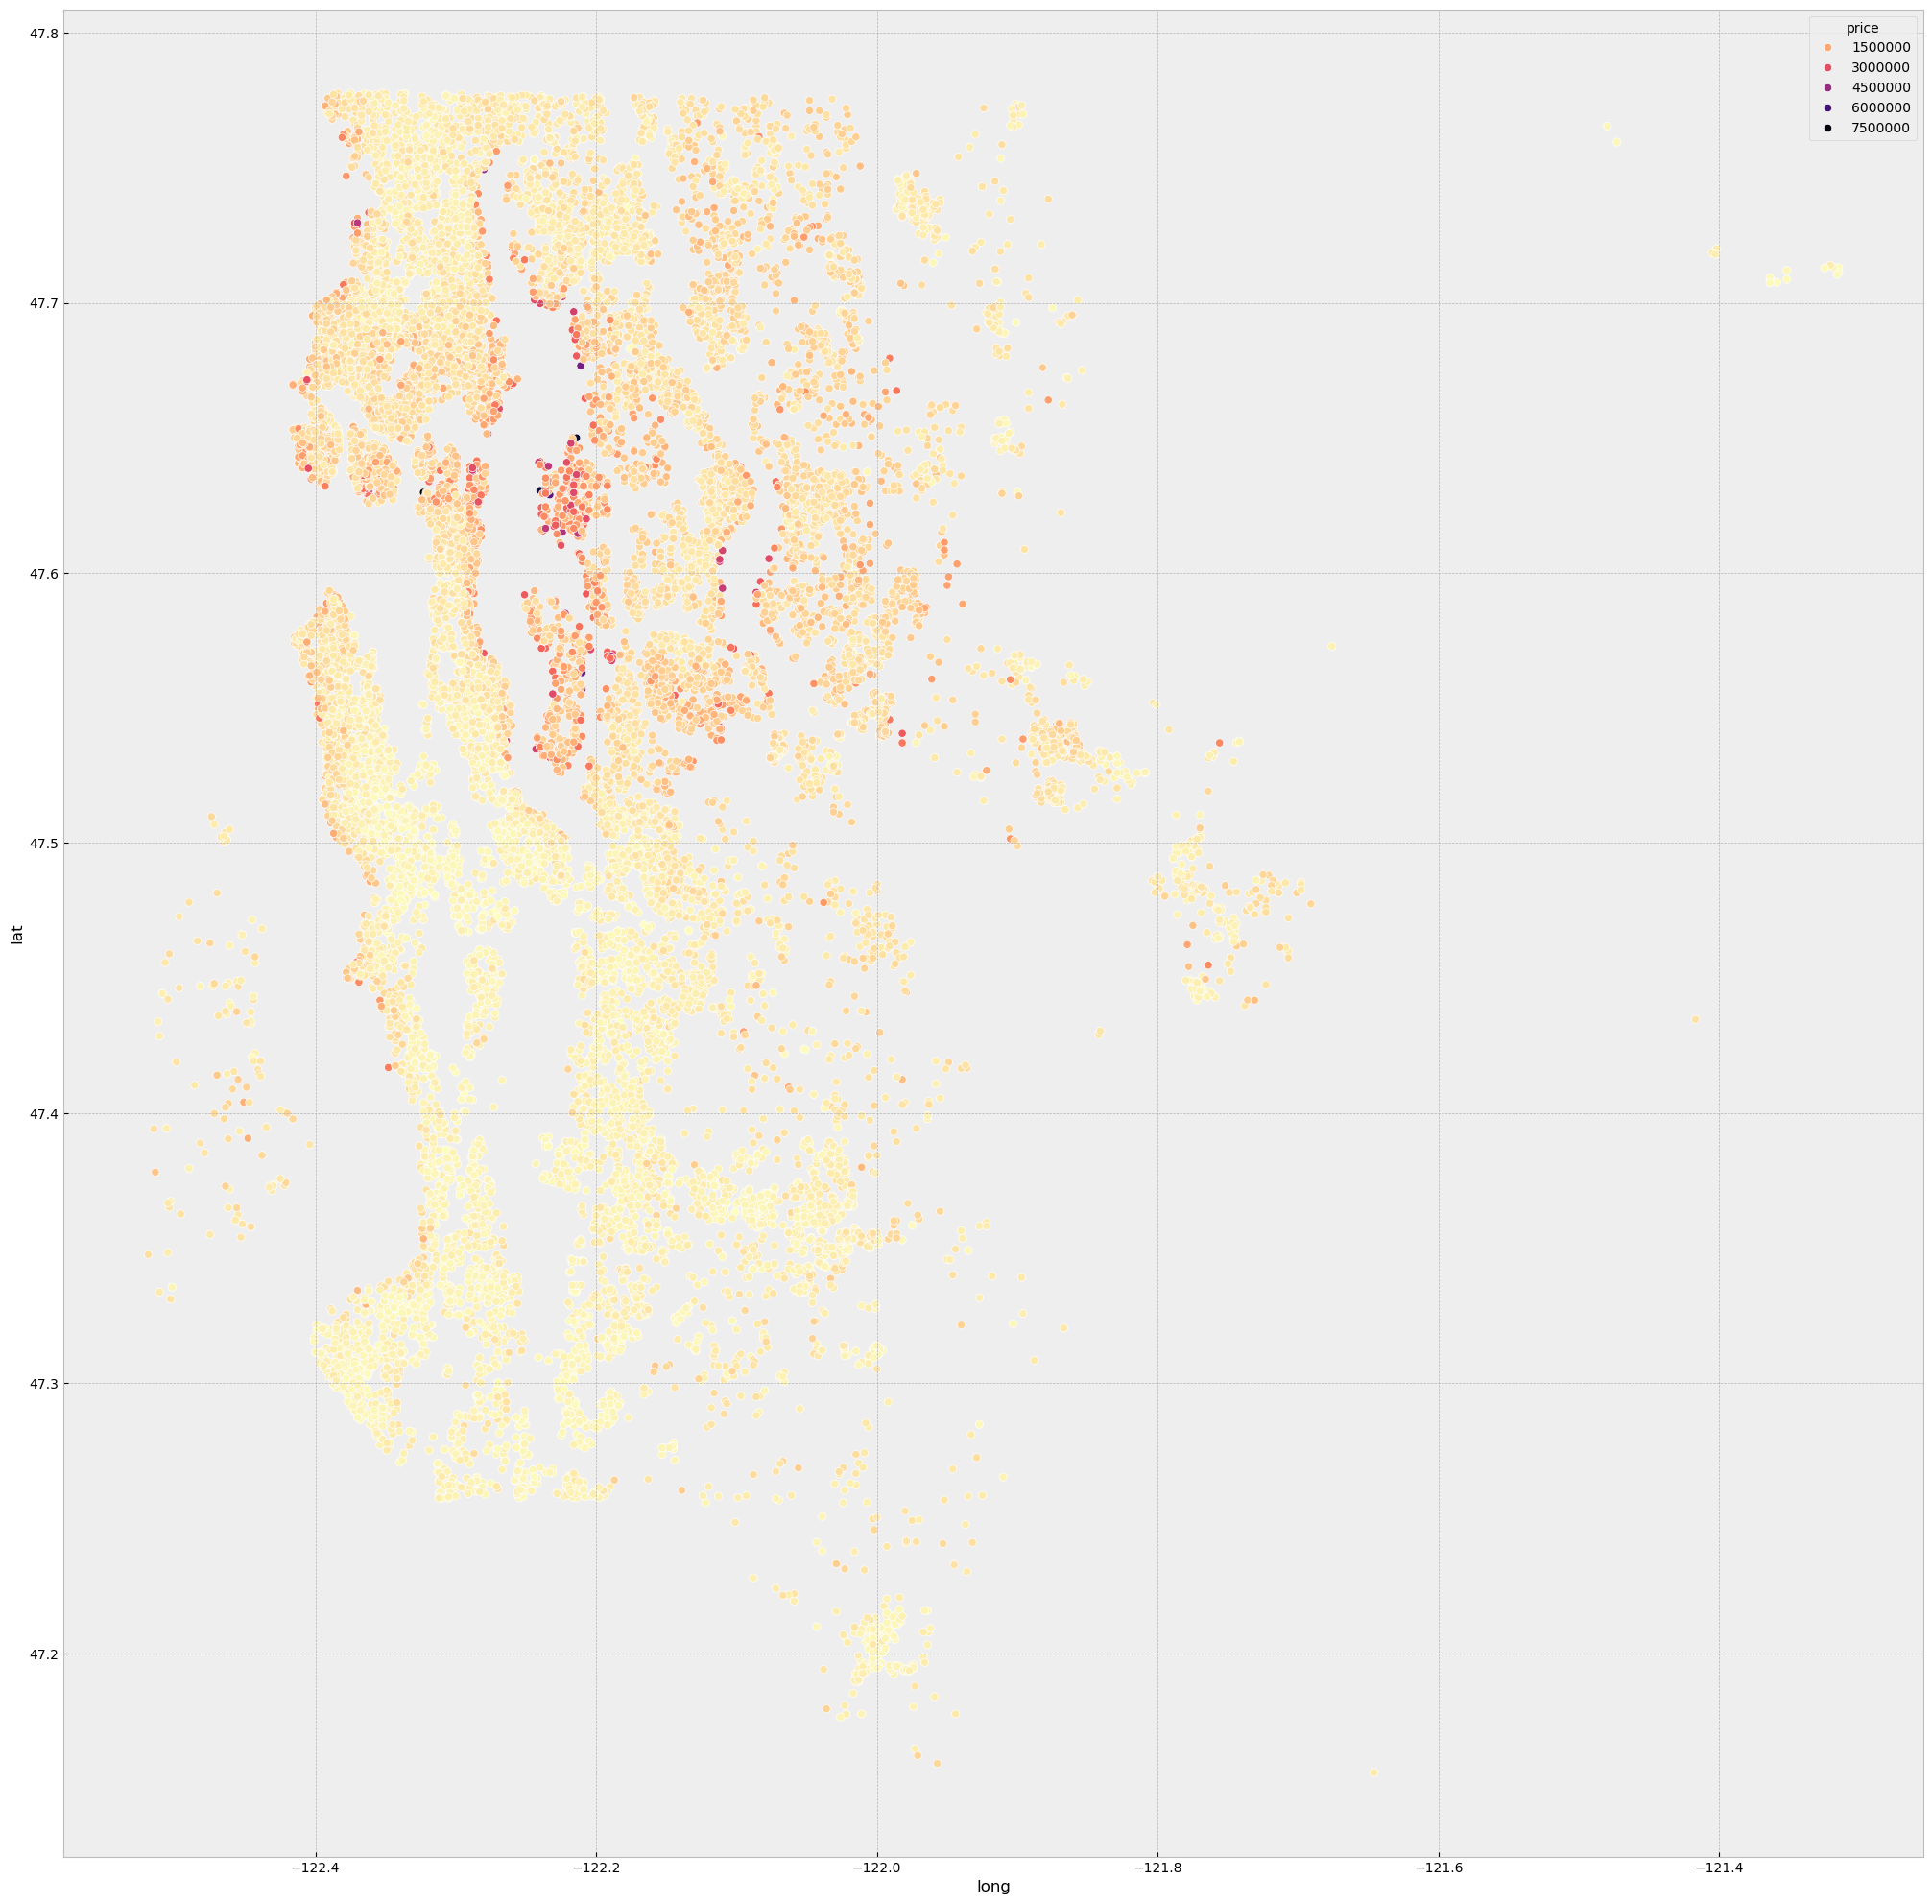

In [37]:
# plotting latitude and longitude as a visual scatter plot to look for location outliers

plt.figure(figsize=(25,25))

sns.scatterplot(data=df, x="long", y="lat", hue="price", palette="magma_r");

In [38]:
# Save the cleaned DataFrame to a CSV file in the 'data' directory
df.to_csv('data/King_country_house_clean_long_lat_dupl_minus.csv',index=False)

Data Exploration

In [39]:
df.shape

(20818, 24)

CORRELATION MATRIX

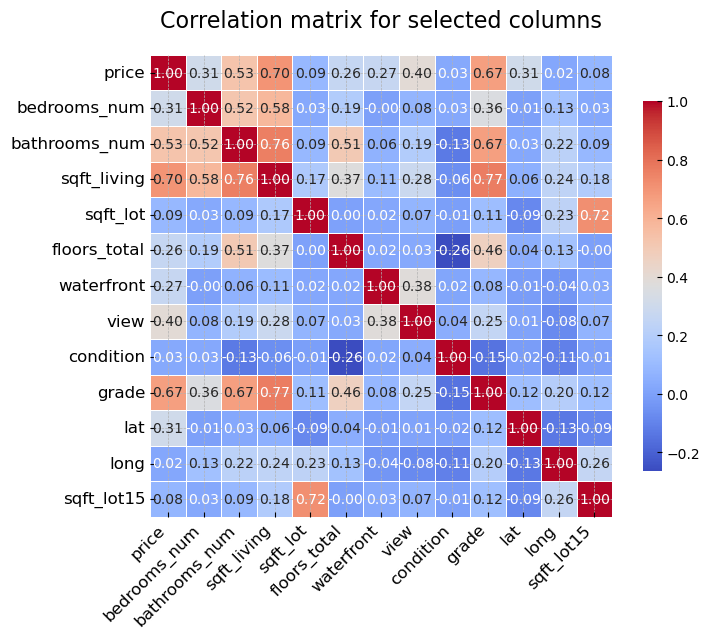

In [40]:
selected_columns = ['price', 'bedrooms_num', 'bathrooms_num', 'sqft_living', 'sqft_lot','floors_total','waterfront','view','condition','grade','lat','long','sqft_lot15']
correlation_matrix = df[selected_columns].corr()

# Set the dimensions of the plot
plt.figure(figsize=(8, 6))

# Generate a heatmap to visualize relationships between variables
sns.heatmap(correlation_matrix, 
            annot=True,         # Show the correlation coefficient in each cell
            fmt=".2f",          
            cmap="coolwarm",    
            square=True,        
            linewidths=0.5,     
            cbar_kws={"shrink": 0.8})  


plt.title("Correlation matrix for selected columns", fontsize=16, pad=20)

plt.xticks(fontsize=12, rotation=45, ha="right")  
plt.yticks(fontsize=12)

plt.show()

⇧ High
0.76 - Bathrooms & Sqft Living
0.76 - Sqft Living & Grade
0.72 - Sqft Lot & Neighboring Lots

⇪ Strong
0.70 - Price & Sqft Living

Moderate
0.67 - Price & Grade
0.58 - Bedrooms & Sqft Living
0.53 - Price & Bathrooms
0.40 - Price & View
0.35 - Floors & Price

⇩ Low
Location (Lat/Long)

In [42]:
correlation_matrix['price']

price            1.000000
bedrooms_num     0.307825
bathrooms_num    0.528232
sqft_living      0.702247
sqft_lot         0.088177
floors_total     0.262490
waterfront       0.267043
view             0.395821
condition        0.032108
grade            0.668115
lat              0.308553
long             0.019839
sqft_lot15       0.081158
Name: price, dtype: float64

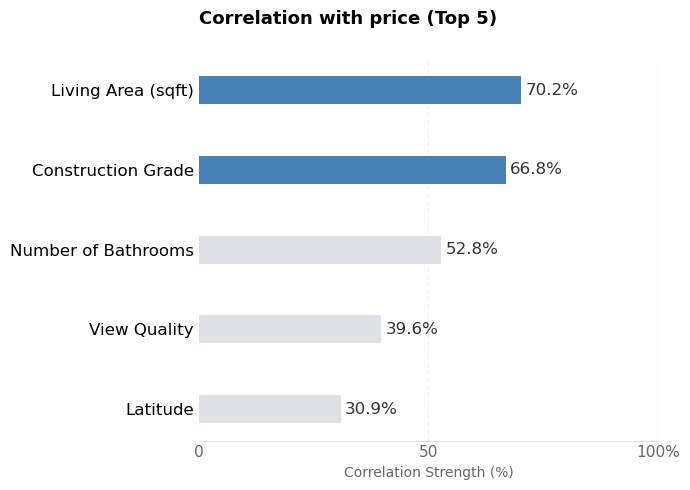

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd


top_5_data = correlation_matrix['price'].drop('price', errors='ignore').sort_values(ascending=True).tail(5)

df_plot = pd.DataFrame({
    'feature': top_5_data.index,
    'importance_pct': top_5_data.values * 100
})

feature_labels = {
    'sqft_living': 'Living Area (sqft)',
    'grade': 'Construction Grade',
    'sqft_above': 'Area Above Ground',
    'sqft_living15': 'Living Area (Neighbors)',
    'bathrooms_num': 'Number of Bathrooms',
    'view': 'View Quality',
    'lat': 'Latitude',
    'waterfront': 'Waterfront View'
}
df_plot['label'] = df_plot['feature'].map(feature_labels).fillna(df_plot['feature'])


plt.figure(figsize=(7, 5), facecolor='white')
ax = plt.gca()
ax.set_facecolor('white') # Убираем серый фон области рисования
ax.grid(False)


colors = ['#dee2e6'] * 3 + ['#4682B4'] * 2 


bars = ax.barh(df_plot['label'], df_plot['importance_pct'], 
                color=colors, height=0.35, zorder=3)

ax.tick_params(axis='y', labelsize=12)

ax.set_xlim(0, 100)
ax.set_xticks([0, 50, 100])
ax.set_xticklabels(['0', '50', '100%'], fontsize=11, color='#666666')


ax.axvline(x=50, color='#f1f3f5', linestyle='--', linewidth=1, zorder=1)
ax.axvline(x=100, color='#e9ecef', linestyle='-', linewidth=1, zorder=1)


for bar in bars:
    width = bar.get_width()
    ax.text(width + 1, bar.get_y() + bar.get_height()/2, 
             f'{width:.1f}%', 
             va='center', ha='left', fontsize=12, color='#333333')


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False) # Названия "висят" в воздухе
ax.spines['bottom'].set_visible(True)
ax.spines['bottom'].set_color('#dee2e6')


ax.tick_params(axis='both', which='both', length=0)


plt.title('Correlation with price (Top 5)', 
          fontsize=13, fontweight='bold', pad=25, loc='left')

plt.xlabel('Correlation Strength (%)', fontsize=10, color='#666666')

plt.tight_layout()
plt.show()

In [ ]:
# Distribution of floor counts across the dataset

df_floor = df['floors_total'].value_counts().to_frame()
df_floor

,count
floors_total,
1.0,10363
2.0,7937
1.5,1839
3.0,522
2.5,152
3.5,5


Hause price distribution

<Axes: xlabel='long', ylabel='lat'>

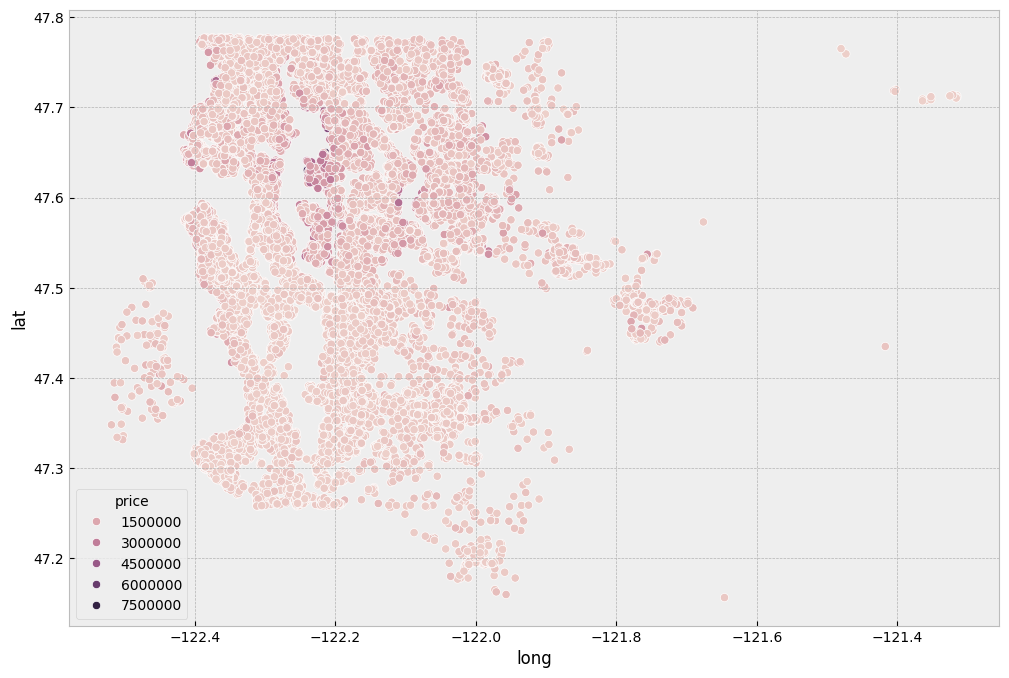

In [ ]:
# Geographic distribution: Mapping properties by coordinates to identify expensive neighborhoods
plt.figure(figsize=(12, 8))
sns.scatterplot(x='long', y='lat', data=df, hue='price')

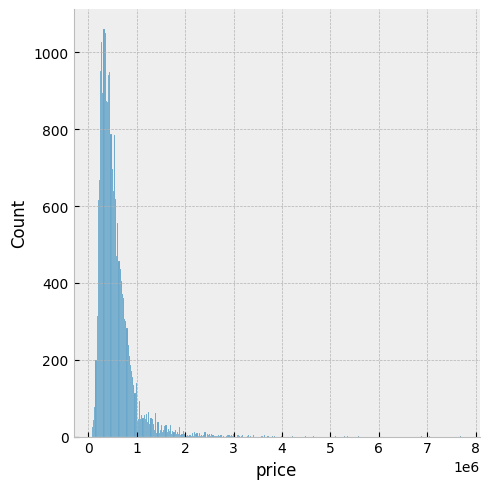

In [ ]:
# Visualize the price distribution
#plt.figure(figsize = (17, 5))
sns.displot(df['price'])

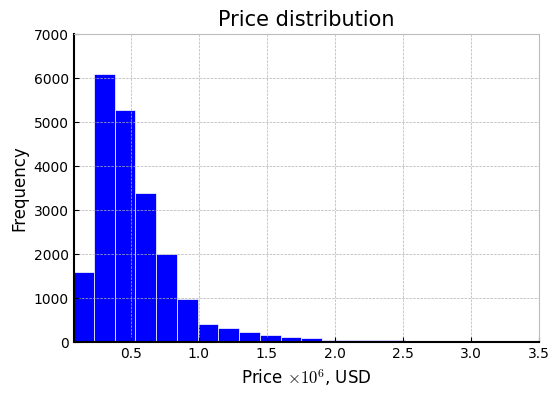

In [ ]:
# Create a polished histogram for price distribution
plt.figure(figsize=(6,4))
# Dividing by 1,000,000 to improve readability of the X-axis
plt.hist(df['price']/ 1000000, bins= 50, edgecolor='w',color='blue')
# Formatting and labeling
plt.title('Price distribution', fontsize=15)
plt.xlabel('Price $\\times 10^6$, USD', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Focusing on the 80k to 3.5M range to exclude extreme outliers
plt.xlim(0.08, 3.5)  
plt.ylim(0, 7000)  

# Customizing plot aesthetics for a clean "white-grid" look
plt.gca().set_facecolor('white')
plt.gcf().set_facecolor("white")   

plt.gca().spines['left'].set_color("black")   
plt.gca().spines['left'].set_linewidth(1.5)   
plt.gca().spines['bottom'].set_color("black") 
plt.gca().spines['bottom'].set_linewidth(1.5)

plt.show()

Min price: $ 78 000

Max price: $ 7,7 million

Living Area Distribution (sqft_living)
Visualizing the distribution of living space to identify the most common property sizes and detect potential outliers in square footage.

<Axes: xlabel='sqft_living', ylabel='Count'>

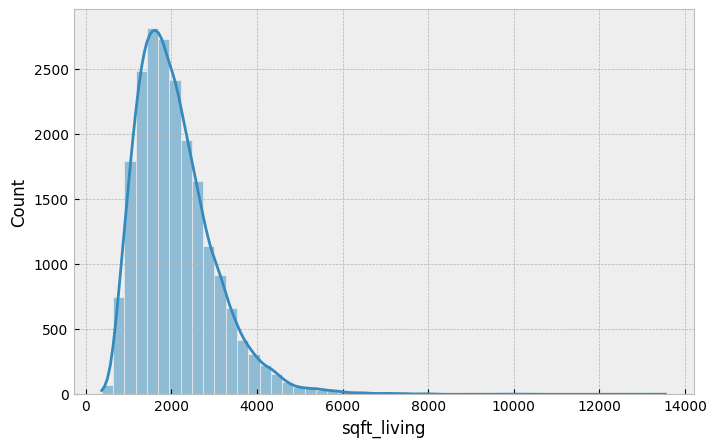

In [ ]:
#The `sqft_living` variable is often the strongest predictor of house price.
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='sqft_living',bins=50, kde=True)

In [ ]:
## Calculate the correlation of all features specifically with the house price
cor=df.corr()['price'].sort_values(ascending=False).drop(['price', 'zipcode','house_id','sales_id','sqft_above','sqft_living15','date'])

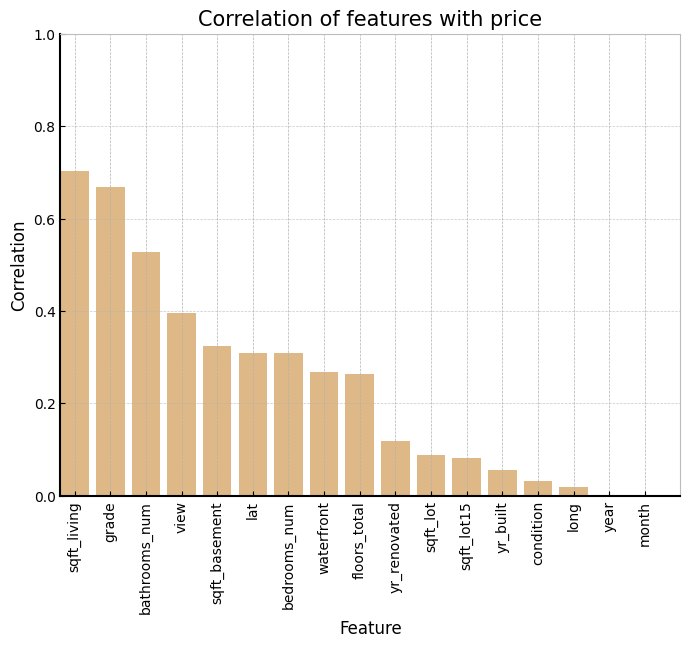

In [ ]:
plt.figure(figsize=(8,6)) #the figure size
plt.bar(x=list(cor.index), height=list(cor.values), color='BurlyWood')
plt.xticks(rotation=90)
#Labeling the axes and setting the title
plt.xlabel('Feature', fontsize=12)
plt.ylabel('Correlation', fontsize=12)
plt.title('Correlation of features with price', fontsize=15)


plt.gca().set_facecolor("white")  # Clean white background
plt.gcf().set_facecolor("white")   

plt.grid(axis='y', linestyle='--', alpha=0.7)
# Strengthening the axis lines
plt.gca().spines['left'].set_color("black")   
plt.gca().spines['left'].set_linewidth(1.5)   
plt.gca().spines['bottom'].set_color("black") 
plt.gca().spines['bottom'].set_linewidth(1.5) 
# Setting the scale from 0 to 1 (Max possible correlation)
plt.ylim(0, 1)  

plt.xlim(-0.4, 17)  


plt.show()

Bedrooms and Bathrooms

In [ ]:
## Convert 'bedrooms_num' from float to integer for data consistency
df['bedrooms_num'] = df['bedrooms_num'].astype(int)

<Axes: xlabel='bedrooms_num', ylabel='Count'>

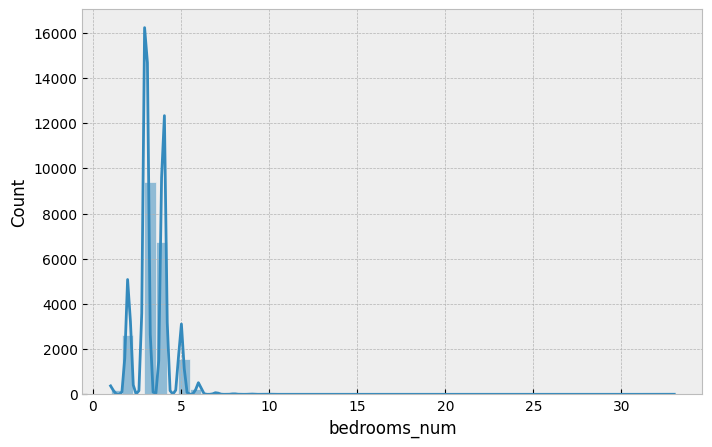

In [ ]:
## Analyze the frequency distribution of bedrooms
plt.figure(figsize=(8,5))
sns.histplot(df['bedrooms_num'],bins=50,kde=True)

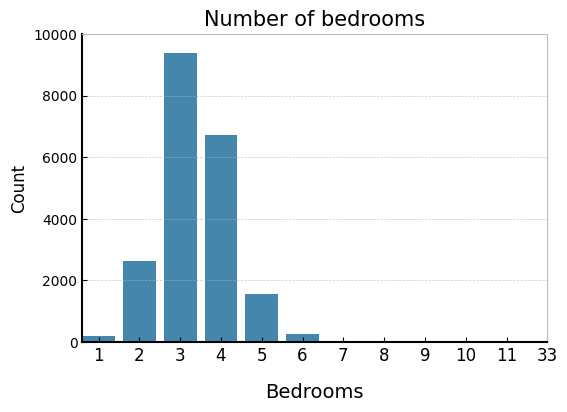

In [ ]:
## Create a refined count plot to show the distribution of bedrooms
plt.figure(figsize=(6,4))
sns.countplot(x='bedrooms_num',data=df)
plt.title('Number of bedrooms', fontsize=15)
plt.xlabel('Bedrooms', fontsize=14, labelpad=13)
plt.ylabel('Count', fontsize=12)


plt.gca().set_facecolor("white")  
plt.gcf().set_facecolor("white")  

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.gca().spines['left'].set_color("black")   
plt.gca().spines['left'].set_linewidth(1.5)   
plt.gca().spines['bottom'].set_color("black") 
plt.gca().spines['bottom'].set_linewidth(1.5) 

plt.ylim(0, 10000) 

plt.xticks(fontsize=12)

plt.xlim(-0.4, 11)  

plt.show()

<Axes: xlabel='bedrooms_num', ylabel='price'>

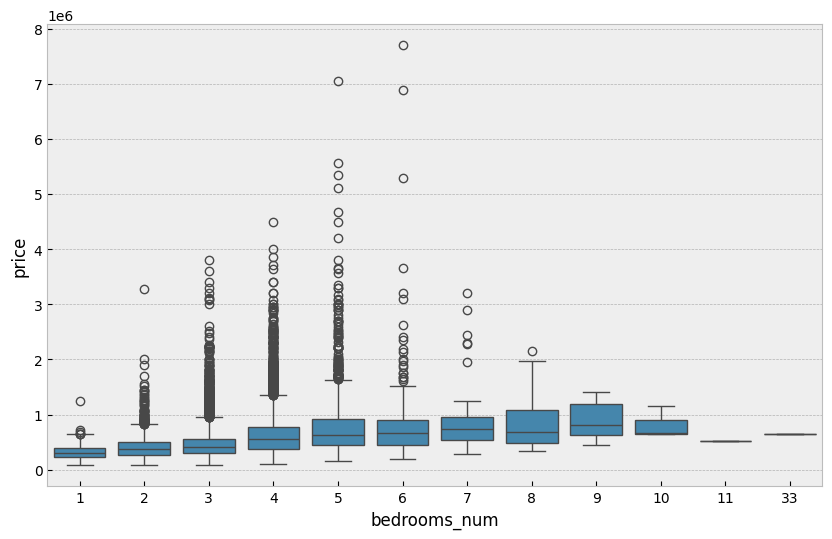

In [ ]:
# Visualize the relationship between the number of bedrooms and price
plt.figure(figsize=(10,6))
# Boxplot helps identify the median price, quartiles, and outliers for each bedroom category
sns.boxplot(x='bedrooms_num',y='price', data=df)

<Axes: xlabel='bathrooms_num', ylabel='Count'>

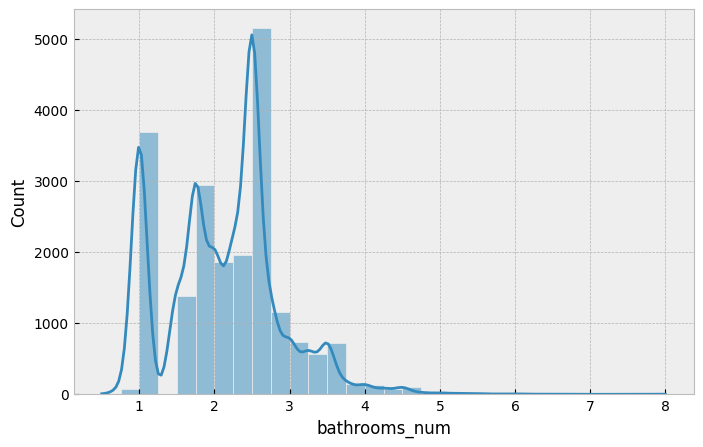

In [ ]:
# Visualize the distribution of bathrooms to understand common property features
plt.figure(figsize=(8,5))
sns.histplot(df['bathrooms_num'],bins=30,kde=True)

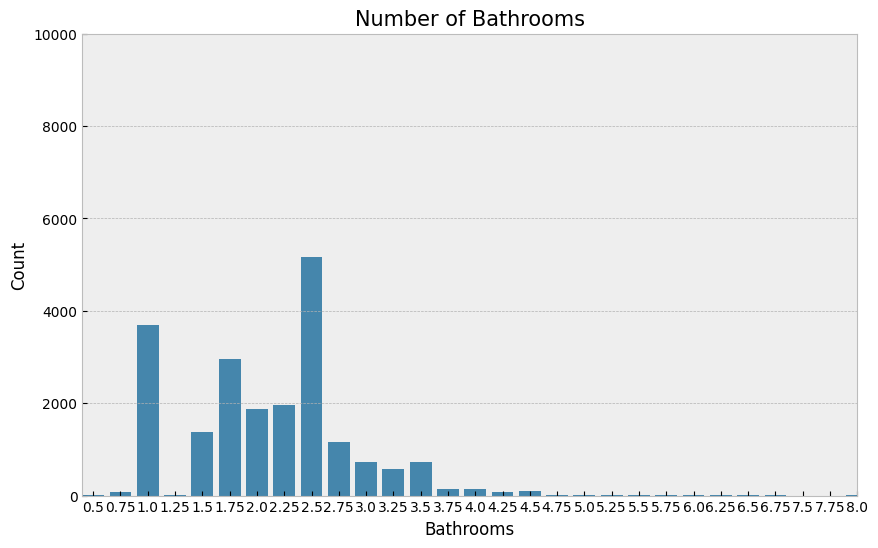

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(x='bathrooms_num',data=df)
plt.title('Number of Bathrooms', fontsize=15)
plt.xlabel('Bathrooms', fontsize=12)
plt.ylabel('Count', fontsize=12)

plt.ylim(0, 10000)  

plt.xlim(-0.4, 28)  
plt.show()

Relationship Between Pricing and Interior Features

To understand how domestic amenities drive market value, I visualized the price distribution across different bedroom and bathroom counts. 

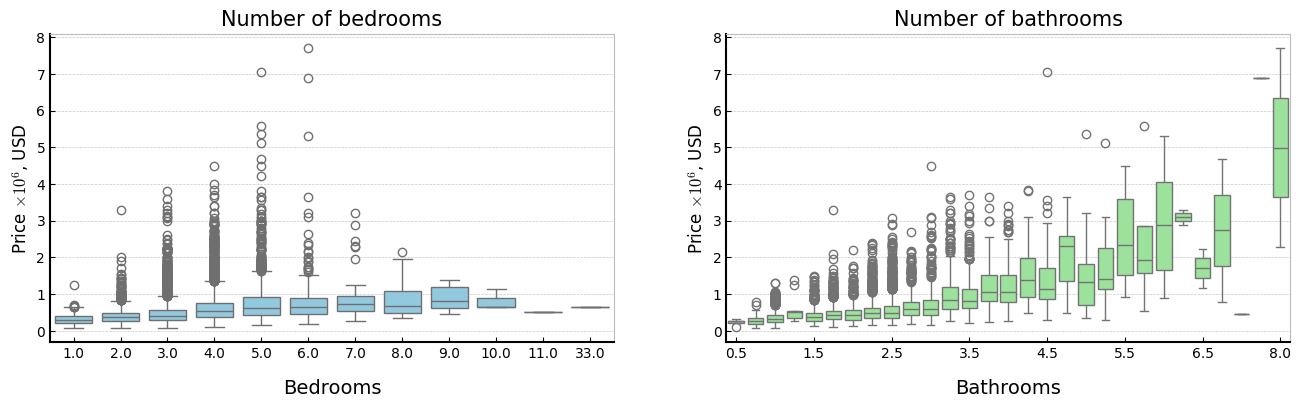

In [ ]:
from matplotlib.ticker import MaxNLocator

plt.figure(figsize=(16,4))
plt.subplot(1,2,1)
sns.boxplot(x='bedrooms_num', y=df['price']/ 1000000, data=df, color='skyblue')
plt.title('Number of bedrooms', fontsize=15)
plt.xlabel('Bedrooms', fontsize=14, labelpad=13)
plt.ylabel('Price $\\times 10^6$, USD', fontsize=12)


plt.gca().set_facecolor("white")  
plt.gcf().set_facecolor("white")   

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.gca().spines['left'].set_color("black")   
plt.gca().spines['left'].set_linewidth(1.5)   
plt.gca().spines['bottom'].set_color("black") 
plt.gca().spines['bottom'].set_linewidth(1.5) 
plt.subplot(1,2,2)
sns.boxplot(x='bathrooms_num', y=df['price']/ 1000000, data=df, color='lightgreen')

plt.title('Number of bathrooms', fontsize=15)
plt.xlabel('Bathrooms', fontsize=14, labelpad=13)
plt.ylabel('Price $\\times 10^6$, USD', fontsize=12)


plt.gca().set_facecolor("white")  
plt.gcf().set_facecolor("white")   

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.gca().spines['left'].set_color("black")   
plt.gca().spines['left'].set_linewidth(1.5)  
plt.gca().spines['bottom'].set_color("black") 
plt.gca().spines['bottom'].set_linewidth(1.5) #

plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True, prune='both', nbins=9))  
plt.show()

Property Grade vs. Market Value AnalysisGrade

The grade feature represents the construction quality and design of the house. Quality Grade (1-13) - "Average" (7) to "Luxury" (11-13)

(np.float64(-0.5), np.float64(10.5), np.float64(0.0), np.float64(7700000.0))

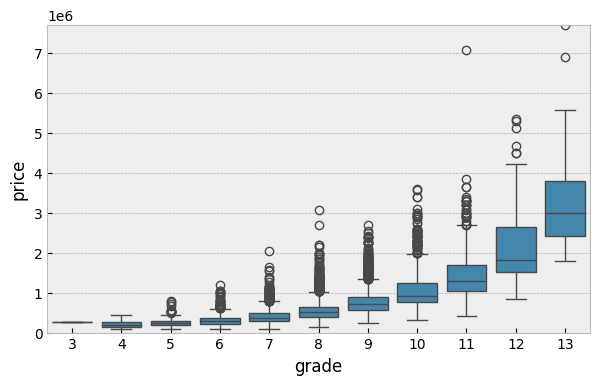

In [842]:
plt.figure(figsize=(7,4))
fig = sns.boxplot(x='grade',y='price', data=df)
fig.axis(ymin=0, ymax=df['price'].max())

Year Built

<Axes: >

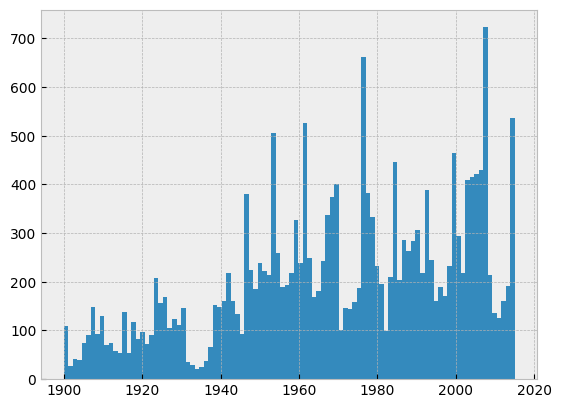

In [843]:
df['yr_built'].hist(bins=100)

Scatter Graph of Price vs Living Space

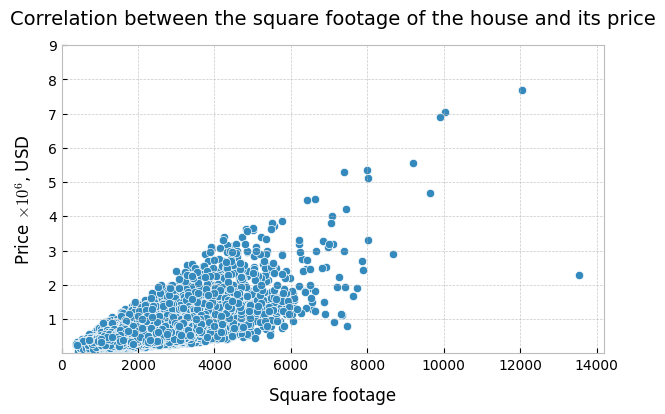

In [852]:
plt.figure(figsize=(7, 4))


sns.scatterplot(x='sqft_living', y=df['price']/ 1000000, data=df)

# Устанавливаем белый фон
plt.gca().set_facecolor("white")  # Белый фон для области графика
plt.gcf().set_facecolor("white")   # Белый фон для всей фигуры

# Настройка сетки для удобства
plt.grid(axis='both', linestyle='--', alpha=0.7)

# Настройка осей
plt.xlabel("Square footage", fontsize=12, labelpad=10)  # Подпись оси X
plt.ylabel('Price $\\times 10^6$, USD', fontsize=12, labelpad=10)          # Подпись оси Y

# Устанавливаем начало осей с нуля
plt.xlim(left=0)  # Ось X начинается с 0
plt.ylim(bottom=0)  # Ось Y начинается с 0

# Устанавливаем параметры для меток на осях
plt.xticks(fontsize=10, rotation=0)  # Шрифт и угол меток на оси X
plt.yticks(plt.yticks()[0][1:],fontsize=10)              # Шрифт меток на оси Y

# Заголовок графика
plt.title("Correlation between the square footage of the house and its price", fontsize=14, pad=15)

# Показать график
plt.show()

In [845]:
df[df['sqft_living']> 10000]

,sales_id,house_id,date,price,bedrooms_num,bathrooms_num,sqft_living,sqft_lot,floors_total,waterfront,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,year,month
3910,3911,9808700762,2014-06-11,7060000.0,5.0,4.5,10040.0,37325.0,2.0,1,...,2360.0,1940,2001,98004,47.6500,-122.214,3930.0,25449.0,2014,06
7245,7246,6762700020,2014-10-13,7700000.0,6.0,8.0,12050.0,27600.0,2.5,0,...,3480.0,1910,1987,98102,47.6298,-122.323,3940.0,8800.0,2014,10
12764,12765,1225069038,2014-05-05,2280000.0,7.0,8.0,13540.0,307752.0,3.0,0,...,4130.0,1999,0,98053,47.6675,-121.986,4850.0,217800.0,2014,05


Outlier Removal and Linear Trend Analysis

The IQR describes the middle 50% of values when ordered from lowest to highest. To find the interquartile range (IQR), ​first find the median (middle value) of the lower and upper half of the data. These values are quartile 1 (Q1) and quartile 3 (Q3). The IQR is the difference between Q3 and Q1.

Оригинальные данные:
        sales_id    house_id       date     price  bedrooms_num  bathrooms_num  \
0             1  7129300520 2014-10-13  221900.0           3.0           1.00   
1             2  6414100192 2014-12-09  538000.0           3.0           2.25   
2             3  5631500400 2015-02-25  180000.0           2.0           1.00   
3             4  2487200875 2014-12-09  604000.0           4.0           3.00   
4             5  1954400510 2015-02-18  510000.0           3.0           2.00   
...         ...         ...        ...       ...           ...            ...   
21592     21593   263000018 2014-05-21  360000.0           3.0           2.50   
21593     21594  6600060120 2015-02-23  400000.0           4.0           2.50   
21594     21595  1523300141 2014-06-23  402101.0           2.0           0.75   
21595     21596   291310100 2015-01-16  400000.0           3.0           2.50   
21596     21597  1523300157 2014-10-15  325000.0           2.0           0.75   

     

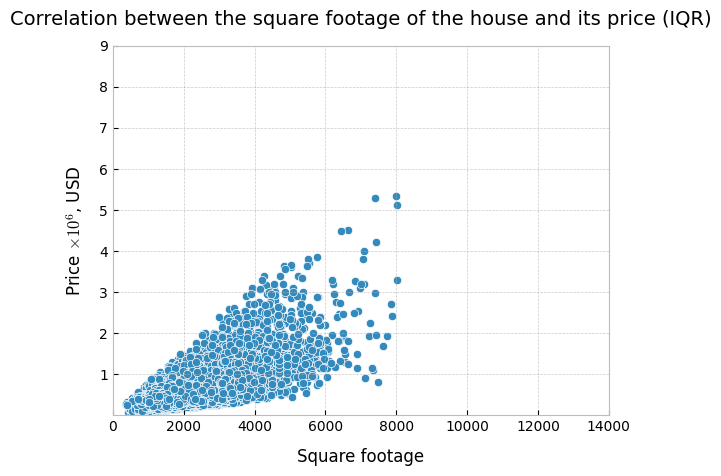

In [ ]:
# 1.Calculate quantile values and Interquartile Range (IQR)
# Using 5th and 95th percentiles to define the boundaries for typical properties
Q1 = df['sqft_living'].quantile(0.05)  
Q3 = df['sqft_living'].quantile(0.95)  
IQR = Q3 - Q1 

# 2. Define upper and lower bounds for outlier detection
# Data points outside these bounds are considered statistical noise
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 3. Filter the dataset to remove extreme outliers
# This ensures the model is trained on representative market data
filtered_data = df[(df['sqft_living'] >= lower_bound) & (df['sqft_living'] <= upper_bound)]

# Display data shape comparison to verify filtering results


sns.scatterplot(x='sqft_living', y=df['price']/ 1000000, data=filtered_data)

plt.gca().set_facecolor("white")  
plt.gcf().set_facecolor("white")   

plt.grid(axis='both', linestyle='--', alpha=0.7)

plt.xlabel("Square footage", fontsize=12, labelpad=10)  
plt.ylabel('Price $\\times 10^6$, USD', fontsize=12, labelpad=10)         


plt.xlim(left=0, right = 14000)  
plt.ylim(bottom=0, top=9)  


plt.xticks(fontsize=10, rotation=0)  
plt.yticks(plt.yticks()[0][1:],fontsize=10)             

plt.title("Correlation between the square footage of the house and its price (IQR)", fontsize=14, pad=15)
plt.show()

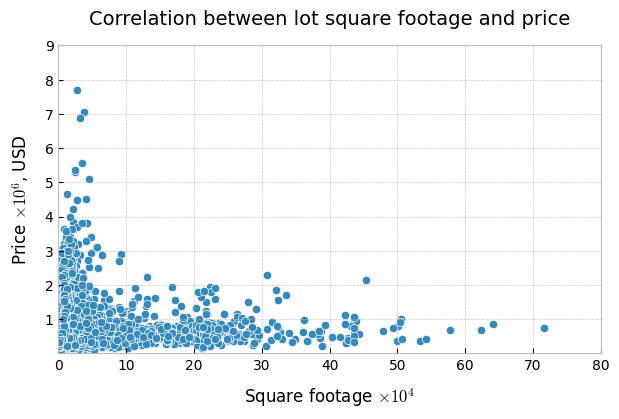

In [ ]:
plt.figure(figsize=(7,4))
sns.scatterplot(x=df['sqft_lot']/10000,y=df['price']/ 1000000, data=df)


plt.gca().set_facecolor("white")  
plt.gcf().set_facecolor("white")   

plt.grid(axis='both', linestyle='--', alpha=0.7)

plt.xlabel("Square footage $\\times 10^4$", fontsize=12, labelpad=10)  
plt.ylabel('Price $\\times 10^6$, USD', fontsize=12, labelpad=10)          

plt.xlim(left=0, right = 80)  
plt.ylim(bottom=0, top=9)  


plt.xticks(fontsize=10, rotation=0)  
plt.yticks(plt.yticks()[0][1:],fontsize=10)             


plt.title("Correlation between lot square footage and price", fontsize=14, pad=15)

plt.show()

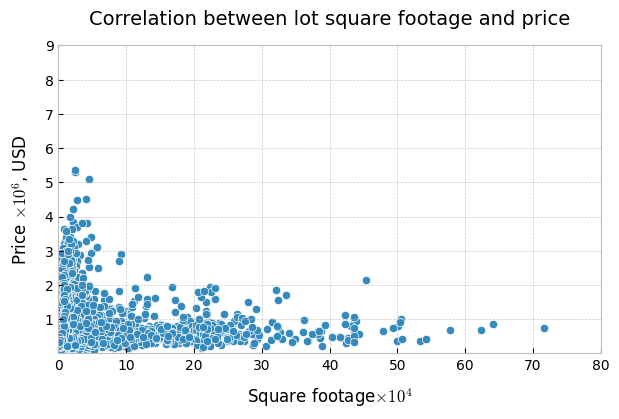

In [ ]:
plt.figure(figsize=(7,4))
sns.scatterplot(x=filtered_data['sqft_lot']/10000,y=filtered_data['price']/ 1000000, data=filtered_data)


plt.gca().set_facecolor("white")  
plt.gcf().set_facecolor("white")   


plt.grid(axis='both', linestyle='--', alpha=0.7)


plt.xlabel("Square footage$\\times 10^4$", fontsize=12, labelpad=10)  
plt.ylabel('Price $\\times 10^6$, USD', fontsize=12, labelpad=10)          


plt.xlim(left=0, right = 80)  
plt.ylim(bottom=0, top=9)  


plt.xticks(fontsize=10, rotation=0)  
plt.yticks(plt.yticks()[0][1:],fontsize=10)             

plt.title("Correlation between lot square footage and price", fontsize=14, pad=15)

plt.show()

Outlier Threshold Optimization

Оригинальные данные:
        sales_id    house_id       date     price  bedrooms_num  bathrooms_num  \
0             1  7129300520 2014-10-13  221900.0           3.0           1.00   
1             2  6414100192 2014-12-09  538000.0           3.0           2.25   
2             3  5631500400 2015-02-25  180000.0           2.0           1.00   
3             4  2487200875 2014-12-09  604000.0           4.0           3.00   
4             5  1954400510 2015-02-18  510000.0           3.0           2.00   
...         ...         ...        ...       ...           ...            ...   
21592     21593   263000018 2014-05-21  360000.0           3.0           2.50   
21593     21594  6600060120 2015-02-23  400000.0           4.0           2.50   
21594     21595  1523300141 2014-06-23  402101.0           2.0           0.75   
21595     21596   291310100 2015-01-16  400000.0           3.0           2.50   
21596     21597  1523300157 2014-10-15  325000.0           2.0           0.75   

     

(0.0, 9.0)

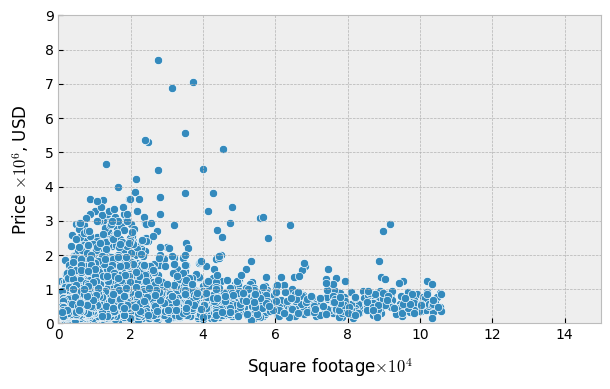

In [ ]:
# 1. Statistical Outlier Detection for Lot Size (sqft_lot)
# Using the 5th and 95th percentiles to define a broader "normal" range

Q1 = df['sqft_lot'].quantile(0.05)  
Q3 = df['sqft_lot'].quantile(0.95)  
IQR = Q3 - Q1  


# 2. Calculating the outlier boundaries
# The 1.5 multiplier is a standard Tukey's Fence threshold
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 3.Filtering the dataset
# This removes extreme estates to focus on typical residential lots
filtered_data_lot = df[(df['sqft_lot'] >= lower_bound) & (df['sqft_lot'] <= upper_bound)]


# Visualization: Price vs. Lot Size
plt.figure(figsize=(7,4))
sns.scatterplot(x=filtered_data_lot['sqft_lot']/ 10000,y=filtered_data_lot['price']/ 1000000, data=filtered_data_lot)

plt.xlabel("Square footage$\\times 10^4$", fontsize=12, labelpad=10)  
plt.ylabel('Price $\\times 10^6$, USD', fontsize=12, labelpad=10)         

plt.xlim(left=0, right = 15)  
plt.ylim(bottom=0, top=9)  



In [927]:
filtered_data_lot.shape

(20282, 24)

In [889]:
filtered_data_lot.sqft_lot.sort_values().tail(10)

8866     83199.0
9189     83199.0
8854     83200.0
9792     83231.0
1054     84267.0
3716     84506.0
577      84942.0
14661    85226.0
4961     85377.0
11511    85377.0
Name: sqft_lot, dtype: float64

Оригинальные данные:
        sales_id    house_id       date     price  bedrooms_num  bathrooms_num  \
0             1  7129300520 2014-10-13  221900.0           3.0           1.00   
1             2  6414100192 2014-12-09  538000.0           3.0           2.25   
2             3  5631500400 2015-02-25  180000.0           2.0           1.00   
3             4  2487200875 2014-12-09  604000.0           4.0           3.00   
4             5  1954400510 2015-02-18  510000.0           3.0           2.00   
...         ...         ...        ...       ...           ...            ...   
21592     21593   263000018 2014-05-21  360000.0           3.0           2.50   
21593     21594  6600060120 2015-02-23  400000.0           4.0           2.50   
21594     21595  1523300141 2014-06-23  402101.0           2.0           0.75   
21595     21596   291310100 2015-01-16  400000.0           3.0           2.50   
21596     21597  1523300157 2014-10-15  325000.0           2.0           0.75   

     

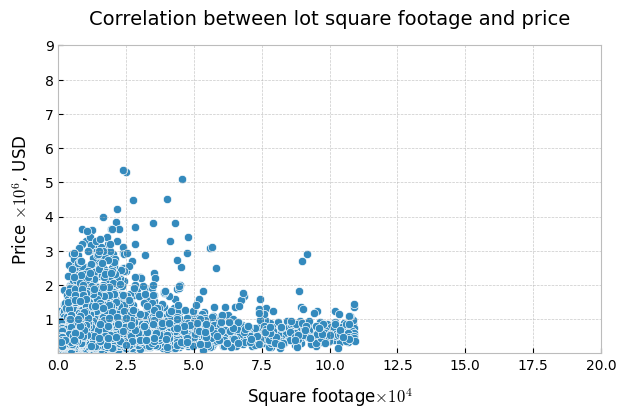

In [ ]:
# 1. Statistical Outlier Detection for Lot Size (sqft_lot)
# Using the 5th and 95th percentiles to define a broader "normal" range
Q1 = filtered_data['sqft_lot'].quantile(0.05)  
Q3 = filtered_data['sqft_lot'].quantile(0.95)  
IQR = Q3 - Q1  # Межквартильный размах


# 2.Define the sensitivity of the outlier detection filter # We use a 1.6 multiplier (instead of the standard 1.5) to slightly expand # the range of "normal" data. This ensures that valuable high-end properties # are not accidentally removed while still filtering out extreme anomalies.
lower_bound = Q1 - 1.6 * IQR
upper_bound = Q3 + 1.6 * IQR

# 3. Filtering the dataset
filtered_doubl_data_lot = filtered_data[(filtered_data['sqft_lot'] >= lower_bound) & (filtered_data['sqft_lot'] <= upper_bound)]

# Visualization: Price vs. Lot Size

plt.figure(figsize=(7,4))
sns.scatterplot(x=filtered_doubl_data_lot['sqft_lot']/10000,y=filtered_doubl_data_lot['price']/ 1000000, data=filtered_doubl_data_lot)

plt.gca().set_facecolor("white")  
plt.gcf().set_facecolor("white")   

plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.xlabel("Square footage$\\times 10^4$", fontsize=12, labelpad=10)  
plt.ylabel('Price $\\times 10^6$, USD', fontsize=12, labelpad=10)         


plt.xlim(left=0, right = 20)  
plt.ylim(bottom=0, top=9)  

plt.xticks(fontsize=10, rotation=0)  
plt.yticks(plt.yticks()[0][1:],fontsize=10)        

plt.title("Correlation between lot square footage and price", fontsize=14, pad=15)

plt.show()



Final Decision on Data Refinement:

After testing different thresholds, I selected a 1.6 multiplier for the IQR-based outlier detection. This decision was made to strike a balance between statistical cleanliness and data preservation.

While 1.5 is the standard, the 1.6 coefficient is more appropriate for the King County real estate market. It allows the model to retain valid premium-segment properties that a stricter filter would have discarded, while still successfully removing extreme, non-representative anomalies.

The resulting dataset is robust, representative of both mid-range and luxury segments, and is now saved as a clean version for the modeling phase.

In [945]:
filtered_doubl_data_lot.shape

(20379, 24)

Saving the filtered dataset to a CSV file for the next modeling stage
This version uses the custom 1.6*IQR threshold for outlier removal

In [951]:
filtered_doubl_data_lot.to_csv('data/King_country_house_clean_long_lat_dupl_minus_IQRsq.csv',index=False)